# ML pipeline results

This notebook presents the saved outputs from the daily sales forecasting pipeline. It does not rerun model training.

The results are organized by the pipeline stages: validation, tuning, model comparison, forecasting, and actual-versus-predicted analysis.

## Setup

In [12]:
# import libraries
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

RESULTS_DIR = Path("results")
print(f"Results directory: {RESULTS_DIR.resolve()}")
print(f"Directory exists: {RESULTS_DIR.exists()}")

Results directory: /Users/Hardisk_WeiFeng/AIAP/neural-network-experiments/ts/results
Directory exists: True


## Saved pipeline outputs

In [13]:
# list saved artifacts
artifact_paths = sorted(path for path in RESULTS_DIR.rglob("*") if path.is_file())
artifacts = pd.DataFrame({"artifact": [str(path.relative_to(RESULTS_DIR)) for path in artifact_paths]})
display(artifacts if not artifacts.empty else pd.DataFrame({"artifact": ["No saved results yet. Run src.ml_experiment first."]}))

,artifact
0,.DS_Store
1,.gitkeep
2,forecast.png
3,forecast_errors.csv
4,metrics.json
5,model_comparison.csv
6,model_comparison.png
7,models/baseline.pkl
8,models/baseline_naive_1_day.pkl
9,models/baseline_naive_1_week.pkl


## Data validation before and after cleaning

In [14]:
# load validation results
validation_results = {}
for stage in ["before_cleaning", "after_cleaning"]:
    path = RESULTS_DIR / f"validation_{stage}.csv"
    if path.exists():
        validation_results[stage] = pd.read_csv(path, index_col=0).iloc[:, 0]

if validation_results:
    validation_table = pd.DataFrame(validation_results)
    display(validation_table)
    validation_summary = pd.DataFrame({
        "checks_passed": validation_table.sum(axis=0),
        "checks_total": validation_table.notna().sum(axis=0),
    })
    validation_summary["all_checks_pass"] = validation_table.all(axis=0)
    display(validation_summary)
else:
    print("Validation results have not been saved yet.")

,before_cleaning,after_cleaning
date_parseable,True,True
date_is_datetime,True,True
date_unique,True,True
date_sorted,True,True
daily_coverage,True,True
calendar_matches_date,True,True
calendar_fields_are_int64,True,True
sales_has_no_missing,True,True
sales_nonnegative,True,True
sales_integer_like,True,True


,checks_passed,checks_total,all_checks_pass
before_cleaning,11,12,False
after_cleaning,12,12,True


## Hyperparameter tuning

In [15]:
# load time-series cross-validation results
tuning_path = RESULTS_DIR / "tuning_results.csv"
if tuning_path.exists():
    tuning_results = pd.read_csv(tuning_path)
    display(tuning_results)
else:
    print("Tuning results have not been saved yet.")

,model,cv_rmse,best_params
0,linear_regression,463.064403,"{'fit_intercept': True, 'positive': True, 'tol..."
1,random_forest,527.553925,"{'max_depth': None, 'n_estimators': 100}"
2,knn,553.018715,"{'n_neighbors': 14, 'weights': 'distance'}"
3,neural_network,597.477520,"{'alpha': 0.001, 'hidden_layer_sizes': (128, 6..."


## Hyperparameter grid

In [16]:
# show the hyperparameter grid used for tuning
from time_series_pipeline.pipelines.model_training.nodes import MODEL_PARAM_GRIDS

grid_rows = [
    {
        "model": model_name,
        "parameter": parameter,
        "values": str(values),
    }
    for model_name, parameter_grid in MODEL_PARAM_GRIDS.items()
    for parameter, values in parameter_grid.items()
]
display(pd.DataFrame(grid_rows))

,model,parameter,values
0,linear_regression,fit_intercept,"[True, False]"
1,linear_regression,positive,"[False, True]"
2,linear_regression,tol,"[1e-06, 0.0001]"
3,random_forest,n_estimators,"[100, 200, 300, 500, 800]"
4,random_forest,max_depth,"[None, 20]"
5,neural_network,hidden_layer_sizes,"[(32,), (64,), (32, 16), (64, 32), (64, 32, 16..."
6,neural_network,alpha,"[0.0001, 0.001]"
7,knn,n_neighbors,"[1, 3, 7, 14, 28]"
8,knn,weights,"['uniform', 'distance']"


## Saved models and baseline comparison

In [17]:
# show saved model files and comparison metrics
models_dir = RESULTS_DIR / "models"
if models_dir.exists():
    display(pd.DataFrame({"saved_model": sorted(path.name for path in models_dir.glob("*.pkl"))}))

comparison_path = RESULTS_DIR / "model_comparison.csv"
if comparison_path.exists():
    comparison = pd.read_csv(comparison_path)
    display(comparison)
    best_row = comparison.iloc[0]
    print(f"Best test RMSE: {best_row['model']} ({best_row['test_rmse']:.2f})")
else:
    print("Model comparison has not been saved yet.")

,saved_model
0,baseline.pkl
1,baseline_naive_1_day.pkl
2,baseline_naive_1_week.pkl
3,baseline_seasonal_naive_1_week.pkl
4,knn.pkl
5,linear_regression.pkl
6,neural_network.pkl
7,random_forest.pkl


,model,train_rmse,test_rmse
0,linear_regression,392.269109,439.770546
1,neural_network,453.412409,589.436679
2,random_forest,151.958311,608.712089
3,knn,0.000332,765.350217
4,naive_1_day,764.819474,855.308817
5,naive_1_week,984.080776,1151.239800


Best test RMSE: linear_regression (439.77)


In [18]:
# create model and baseline RMSE comparison bar plot
comparison_path = RESULTS_DIR / "model_comparison.csv"
if comparison_path.exists():
    comparison = pd.read_csv(comparison_path)
    ordered_comparison = comparison.sort_values("test_rmse")
    labels = ordered_comparison["model"].str.replace("_", " ").str.title()
    figure, axis = plt.subplots(figsize=(10, 6))
    axis.barh(labels, ordered_comparison["test_rmse"])
    axis.set_title("Test RMSE")
    axis.set_xlabel("RMSE")
    axis.set_ylabel("Model")
    axis.grid(axis="x", alpha=0.3)
    figure.suptitle("Model and baseline comparison")
    figure.tight_layout()
    comparison_plot_path = RESULTS_DIR / "model_comparison.png"
    figure.savefig(comparison_plot_path, bbox_inches="tight")
    plt.show()
else:
    print("Model comparison results have not been saved yet.")

/var/folders/z5/t6prsb910p5cn4_p8358dl280000gq/T/ipykernel_92154/3111876844.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Before-and-after regime comparison

All models were evaluated on the same test window, from **2014-10-01 to 2016-05-22**. The post-regime variant removes observations before **2012-06-01**. Negative RMSE change means performance improved after removal.

| Model | All data RMSE | Post-regime RMSE | Change |
|---|---:|---:|---:|
| Random forest | 519.15 | 557.05 | +37.90 |
| Linear regression | 535.43 | 590.79 | +55.36 |
| Neural network | 583.40 | **569.29** | -14.10 |
| KNN | 589.37 | 570.98 | -18.39 |
| Naive, one week | 825.21 | 825.21 | 0.00 |
| Naive, one day | 1,082.63 | 1,082.63 | 0.00 |

The full comparison is saved in `results/regime_model_comparison.csv`.

In [19]:
# load the reproducible before-and-after comparison table
regime_comparison_path = RESULTS_DIR / "regime_model_comparison.csv"
if regime_comparison_path.exists():
    regime_comparison = pd.read_csv(regime_comparison_path)
    display(regime_comparison.round(2))
else:
    print("Regime comparison results have not been saved yet.")

,regime,model,train_rows,test_rows,train_rmse,test_rmse,cv_rmse
0,all_data,knn,976,600,0.00,589.37,622.31
1,post_regime,knn,487,600,0.00,570.98,592.76
2,all_data,linear_regression,976,600,481.79,535.43,555.82
3,post_regime,linear_regression,487,600,517.85,590.79,584.16
4,all_data,naive_1_day,976,600,941.38,1082.63,NaN
5,post_regime,naive_1_day,487,600,971.46,1082.63,NaN
6,all_data,neural_network,976,600,524.62,583.40,671.99
7,post_regime,neural_network,487,600,462.85,569.29,753.30
8,all_data,random_forest,976,600,185.51,519.15,579.64
9,post_regime,random_forest,487,600,191.04,557.05,576.99


## Random forest feature importance

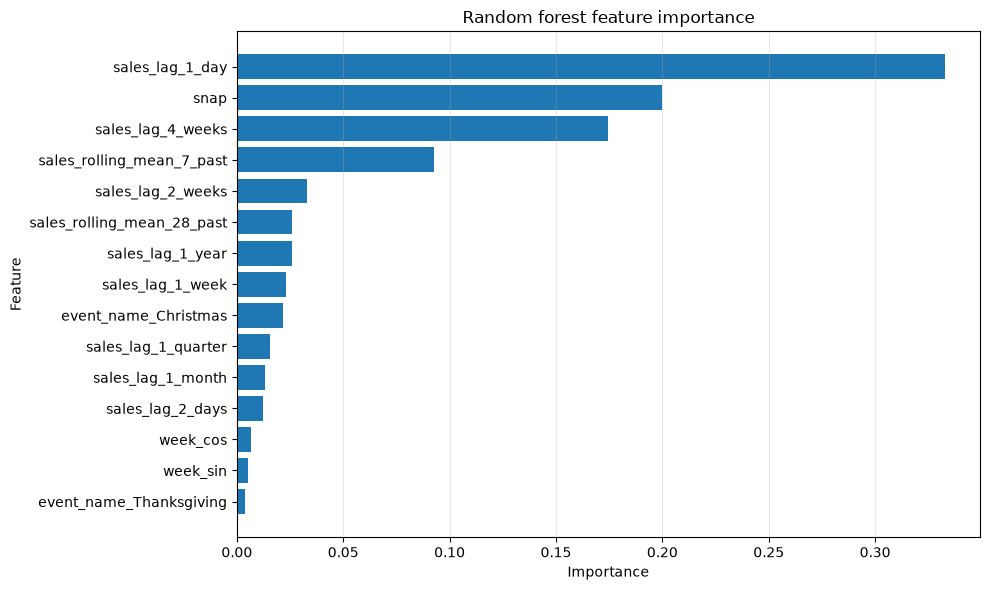

In [20]:
# display the saved random forest feature-importance plot
feature_importance_path = RESULTS_DIR / "random_forest_feature_importance.png"
if feature_importance_path.exists():
    display(Image(filename=str(feature_importance_path)))
else:
    print("Random forest feature importance plot has not been saved yet.")

## Forecast results

In [21]:
# plot actual sales, model forecasts, and both baselines
forecast_path = RESULTS_DIR / "forecast_errors.csv"
if forecast_path.exists():
    forecast = pd.read_csv(forecast_path, index_col=0, parse_dates=True).tail(90)
    forecast_columns = [
        ("prediction", "Model"),
        ("baseline_naive_1_day_prediction", "Naive 1 Day"),
        ("baseline_naive_1_week_prediction", "Naive 1 Week"),
    ]
    available_forecasts = [
        (column, label)
        for column, label in forecast_columns
        if column in forecast
    ]
    fig, axes = plt.subplots(
        len(available_forecasts),
        1,
        figsize=(14, 4 * len(available_forecasts)),
        sharex=True,
    )
    axes = [axes] if len(available_forecasts) == 1 else axes
    for axis, (forecast_column, forecast_label) in zip(axes, available_forecasts):
        axis.plot(forecast.index, forecast["actual"], label="Actual")
        axis.plot(forecast.index, forecast[forecast_column], label=forecast_label)
        axis.set_title(f"Actual vs {forecast_label}")
        axis.set_ylabel("Sales")
        axis.legend()
        axis.grid(alpha=0.3)
    axes[-1].set_xlabel("Date")
    fig.suptitle("Test-period sales forecast (last 90 days)")
    fig.tight_layout()
    fig.autofmt_xdate()
    plt.show()
else:
    print("Forecast results have not been saved yet.")

/var/folders/z5/t6prsb910p5cn4_p8358dl280000gq/T/ipykernel_92154/1862301951.py:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Actual versus predicted sales

In [22]:
# plot predicted versus actual sales with empirical error bounds
forecast_path = RESULTS_DIR / "forecast_errors.csv"
if forecast_path.exists():
    forecast = pd.read_csv(forecast_path, index_col=0, parse_dates=True)
    residuals = forecast["actual"] - forecast["prediction"]
    lower_error = residuals.quantile(0.05, interpolation="lower")
    upper_error = residuals.quantile(0.95, interpolation="higher")
    pearson_correlation = forecast["actual"].corr(
        forecast["prediction"],
        method="pearson",
    )
    print(f"Pearson correlation (actual vs predicted): {pearson_correlation:.4f}")
    print(f"5th percentile error: {lower_error:.0f} units")
    print(f"95th percentile error: {upper_error:.0f} units")

    figure, axis = plt.subplots(figsize=(8, 8))
    axis.scatter(
        forecast["prediction"],
        forecast["actual"],
        alpha=0.35,
        label="Observed sales",
    )
    axis_min = min(forecast["actual"].min(), forecast["prediction"].min())
    axis_max = max(forecast["actual"].max(), forecast["prediction"].max())
    axis.plot(
        [axis_min, axis_max],
        [axis_min, axis_max],
        linestyle="--",
        label="Perfect prediction",
    )
    axis.plot(
        [axis_min, axis_max],
        [axis_min + lower_error, axis_max + lower_error],
        color="tab:orange",
        linestyle=":",
        label="5th percentile error",
    )
    axis.plot(
        [axis_min, axis_max],
        [axis_min + upper_error, axis_max + upper_error],
        color="tab:red",
        linestyle=":",
        label="95th percentile error",
    )
    axis.set_title("Predicted sales vs actual sales")
    axis.set_xlabel("Predicted sales")
    axis.set_ylabel("Actual sales")
    axis.legend()
    axis.grid(alpha=0.3)
    figure.tight_layout()
    figure.savefig(RESULTS_DIR / "predicted_vs_actual_scatter.png", bbox_inches="tight")
    plt.show()
else:
    print("Forecast results have not been saved yet.")

Pearson correlation (actual vs predicted): 0.9112
5th percentile error: -519 units
95th percentile error: 885 units


/var/folders/z5/t6prsb910p5cn4_p8358dl280000gq/T/ipykernel_92154/1004141357.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Summary

Use the validation tables to confirm the cleaning decisions, the tuning table to review model selection, the comparison table to assess improvement over both naive baselines, the actual-versus-predicted plot to review forecast alignment, and the stock-coverage and prediction-interval plots to choose a conservative inventory level.